# Языковые запросы к визуальным признакам картинки с помощью NARADIO

## Preface
Ниже повторено, какие результаты по языковым запросам к визуальным признакам были получены ранее.

[RADIO](https://github.com/NVlabs/RADIO) – агломеративная модель, которая обучалась несколькими учителями (CLIP, SAM, DINOv2, SigLIP2). Модель формирует один вектор эмбедингов и переводит его в пространство эмбедингов учителей с помощью адаптеров (соответственно, по одному адаптеру на учителя): [`clip`, `siglip2-g`, `sam`, `dino_v2`](https://github.com/NVlabs/RADIO?tab=readme-ov-file#huggingface)

Выход модели и адаптеров – это summary и features векторы:
- summary: вектор общих признаков, размер которого зависит от параметров модели (или учителя, если использовался адаптер).
- features: вектор пространственных (плотных) признаков, размер которого зависит от входного изображения (B (HW) C) и размера патчей (16 по умолчанию).

То есть, можно переформулировать нашу задачу так: 
> научиться сегментировать объекты по языковым запросам к вектору пространственных признаков features.

Из всех адаптеорв только `clip`, `siglip2-g` поддерживают языковые запросы. 

У CLIP различается размерность общих и плотных признаков (summary 1024 и features 1280). Текстовые эмбединги находятся именно в пространстве summary, так что без дообучения не получится провести сегментацию по запросу -- нужно либо привести эмбединги текста к пространству плотных признаков, либо привести хитмап к пространству текстовых эмбедингов

При этом SigLIP имеет одинаковые размерности для общих и плотных признаков. Однако они всё равно не совместимы: косинусная симметрия даёт околонулевые значения для любого запроса (то есть, вектора практически перпендикулярны):

<img src=radio_query_mask.png height=700px>

То есть, не обойтись без слоя проекции одного пространства признаков в другое.

Поискал, у кого была похожая задача с RADIO. Нашёл обсуждение того, что нам нужно: https://github.com/NVlabs/RADIO/issues/128 

Там же есть ссылка на ветку с обсуждением маппинга summary в features. В этой ветке люди решили проблему для своих целей и описали исследование: https://rayfronts.github.io/

Кажется, это то, что нам нужно.

## Что предлагают RayFronts

[RayFronts](https://github.com/RayFronts/RayFronts) предложили метод маппинга пространства признаков текста в пространсто признаков картинки с помощью объединени NACLIP и RADIO.

В соответствии с моими предыдущими тестами (и тестами RayFronts) лучше использовать `siglip2-g` адаптер -- он даёт менее шумные признаки.

In [1]:
from transformers import AutoModel, CLIPImageProcessor
import torch
import torchvision
from rayfronts.image_encoders.naradio import NARadioEncoder

input_res = [640, 352]
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

enc = NARadioEncoder(model_version="c-radio_v3-h", lang_model="siglip2-g", # radio_v2.5-b + siglip
                    input_resolution=input_res, device=device)
# 6 GB

/home/bashmac/MIPT/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Unable to import openvdb. Make sure you compiled it. Will not import mappers that depend on it.
ROS2 modules not found !


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Using cache found in /home/bashmac/.cache/torch/hub/NVlabs_RADIO_main


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


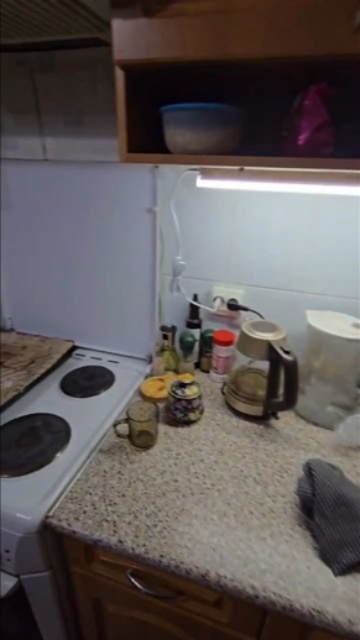

In [2]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor, to_pil_image
from torch.nn import functional as F

input_file = "/home/bashmac/MIPT/test_SLAM/datasets/custom/kitchen_5/results/frame_0014.jpg"

image = Image.open(input_file).convert('RGB')
image

In [3]:
x = pil_to_tensor(image).float().cuda() / 255.0
x = x.unsqueeze(0)
x = F.interpolate(x, input_res, mode='bilinear')
print(f'{x.shape=}')

x.shape=torch.Size([1, 3, 640, 352])


In [4]:
with torch.no_grad():
    feat_map = enc.encode_image_to_feat_map(x)
    # тот самый шаг маппинга пространства плотных признаков к пространству текстовых
    lang_aligned_feat_map = enc.align_spatial_features_with_language(feat_map)
# 6 GB

In [ ]:
queries = ["cup", "teapot", "towel"]
with torch.no_grad():
    text_features = enc.encode_labels(queries)
# without grad: 6.9 GB VM
# with grad: 15.5 GB VM + 11.3 RB Shared mem = 26.8 GB of memory

In [6]:
print(f'{lang_aligned_feat_map.shape=} {text_features.shape=}')

lang_aligned_feat_map.shape=torch.Size([1, 1536, 40, 22]) text_features.shape=torch.Size([3, 1536])


In [7]:
lang_aligned_feat_map_permuted = lang_aligned_feat_map.permute(0, 2, 3, 1)
print(f'{lang_aligned_feat_map_permuted.shape=} {text_features.shape=}')

lang_aligned_feat_map_permuted.shape=torch.Size([1, 40, 22, 1536]) text_features.shape=torch.Size([3, 1536])


In [8]:
with torch.no_grad():
    img_features_expanded = lang_aligned_feat_map_permuted.expand(len(text_features), *lang_aligned_feat_map_permuted.shape[1:]).cuda()
    text_features_expanded = text_features.unsqueeze(1).unsqueeze(1)

    print(img_features_expanded.shape, text_features_expanded.shape)
    similarities = torch.cosine_similarity(img_features_expanded, text_features_expanded, dim=-1).unsqueeze(-1)
    print(f'{similarities.min()=}, {similarities.max()=}')
    similarities.shape

torch.Size([3, 40, 22, 1536]) torch.Size([3, 1, 1, 1536])
similarities.min()=tensor(-0.0638, device='cuda:0', dtype=torch.float16), similarities.max()=tensor(0.1925, device='cuda:0', dtype=torch.float16)


In [9]:
def get_robust_pca(features: torch.Tensor, m: float = 2, remove_first_component=False, skip: int = 0):
    # features: (N, C)
    # m: a hyperparam controlling how many std dev outside for outliers
    assert len(features.shape) == 2, "features should be (N, C)"
    reduction_mat = torch.pca_lowrank(features, q=3 + skip, niter=20)[2]
    reduction_mat = reduction_mat[:, skip:]
    colors = features @ reduction_mat
    if remove_first_component:
        colors_min = colors.min(dim=0).values
        colors_max = colors.max(dim=0).values
        tmp_colors = (colors - colors_min) / (colors_max - colors_min)
        fg_mask = tmp_colors[..., 0] < 0.2
        reduction_mat = torch.pca_lowrank(features[fg_mask], q=3, niter=20)[2]
        colors = features @ reduction_mat
    else:
        fg_mask = torch.ones_like(colors[:, 0]).bool()
    d = torch.abs(colors[fg_mask] - torch.median(colors[fg_mask], dim=0).values)
    mdev = torch.median(d, dim=0).values
    s = d / mdev
    try:
        rins = colors[fg_mask][s[:, 0] < m, 0]
        gins = colors[fg_mask][s[:, 1] < m, 1]
        bins = colors[fg_mask][s[:, 2] < m, 2]
        rgb_min = torch.tensor([rins.min(), gins.min(), bins.min()])
        rgb_max = torch.tensor([rins.max(), gins.max(), bins.max()])
    except:
        rins = colors
        gins = colors
        bins = colors
        rgb_min = torch.tensor([rins.min(), gins.min(), bins.min()])
        rgb_max = torch.tensor([rins.max(), gins.max(), bins.max()])

    return reduction_mat, rgb_min.to(reduction_mat), rgb_max.to(reduction_mat)


def get_pca_map(
    feature_map: torch.Tensor,
    img_size,
    interpolation="bicubic",
    return_pca_stats=False,
    pca_stats=None,
    skip_components: int = 0,
):
    """
    feature_map: (1, h, w, C) is the feature map of a single image.
    """
    if feature_map.shape[0] != 1:
        # make it (1, h, w, C)
        feature_map = feature_map[None]
    if pca_stats is None:
        reduct_mat, color_min, color_max = get_robust_pca(
            feature_map.reshape(-1, feature_map.shape[-1]), skip=skip_components,
        )
    else:
        reduct_mat, color_min, color_max = pca_stats
    pca_color = feature_map @ reduct_mat
    pca_color = (pca_color - color_min) / (color_max - color_min)
    pca_color = pca_color.clamp(0, 1)
    pca_color = F.interpolate(
        pca_color.permute(0, 3, 1, 2),
        size=img_size,
        mode=interpolation,
    ).permute(0, 2, 3, 1)
    pca_color = pca_color.cpu().numpy().squeeze(0)
    if return_pca_stats:
        return pca_color, (reduct_mat, color_min, color_max)
    return pca_color

In [10]:
from typing import List

@torch.no_grad
def get_query_map(enc: NARadioEncoder, text_features: torch.Tensor, features: torch.Tensor) -> torch.Tensor:
    similarity = torch.cosine_similarity(features.cuda(), text_features, dim=-1).unsqueeze(-1)
    similarity = similarity-(-1) / 2
    # similarity = torch.where(similarity > (cos_threshold+1)/2, 1.0, 0.0)
    return similarity.expand(*similarity.shape[:3], 3)

In [11]:
import numpy as np
from einops import rearrange
from PIL import ImageDraw, ImageFont

@torch.no_grad
def upscale_res(tensor, desired_res):
    return torch.nn.functional.interpolate(
        tensor.expand([1, tensor.shape[-3], tensor.shape[-2], 3]).permute(0, 3, 1, 2),
        # tensor.permute(2, 0, 1),
        size=desired_res,
        mode='bilinear',
    ).squeeze(0)

def add_title_to_frame(title: str, frame: torch.Tensor):
    img = to_pil_image(frame, 'RGB')
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf", 16)
    d = ImageDraw.Draw(img)
    height = int(frame.shape[1])
    width = int(frame.shape[2])
    d.text((width//2, 0), title, anchor='ma', font=font, fill='white')
    return pil_to_tensor(img)

@torch.no_grad
def vis_single_similarity_map(query: str, similarity: torch.Tensor, cos_threshold=0.1):
    # features_color = torch.from_numpy(get_pca_map(lang_aligned_feat_map_permuted.float(), input_res)).permute(2, 0, 1).cuda()
    # h, w = similarity.shape[1:3]
    # similarity_united_hw = rearrange(similarity, 'b h w c -> b (h w) c').float()
    # normalized_sim = torch.softmax(similarity_united_hw, dim=1)
    # normalized_sim = rearrange(normalized_sim, 'b (h w) c -> b h w c', h=h, w=w).float()
    normalized_sim = (similarity+1)/2
    similarity_mask = torch.where(similarity > cos_threshold, 1.0, 0.0)
    
    similarity_color = upscale_res(normalized_sim, input_res)
    similarity_mask_scaled = upscale_res(similarity_mask, input_res)
    x_masked = add_title_to_frame(query, x[0] * similarity_mask_scaled) / 255
    # x_masked = (x[0] * similarity_mask_scaled).cuda()

    album = torch.concat((x[0], similarity_color, similarity_mask_scaled, x_masked.cuda()), dim=2)
    # return to_pil_image(add_title_to_frame(query, album))
    return to_pil_image(album)

results = []
for query, sim in zip(queries, similarities):
    results.append(vis_single_similarity_map(query, sim, 0.1))

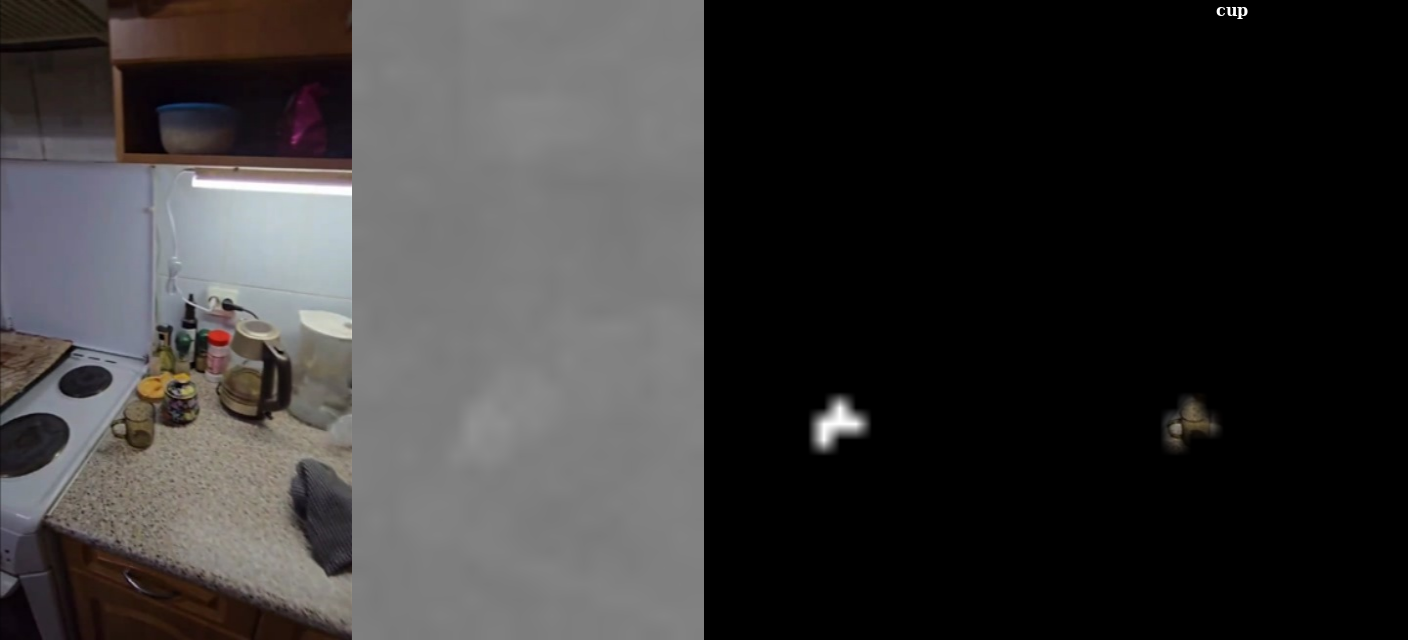

In [12]:
results[0]

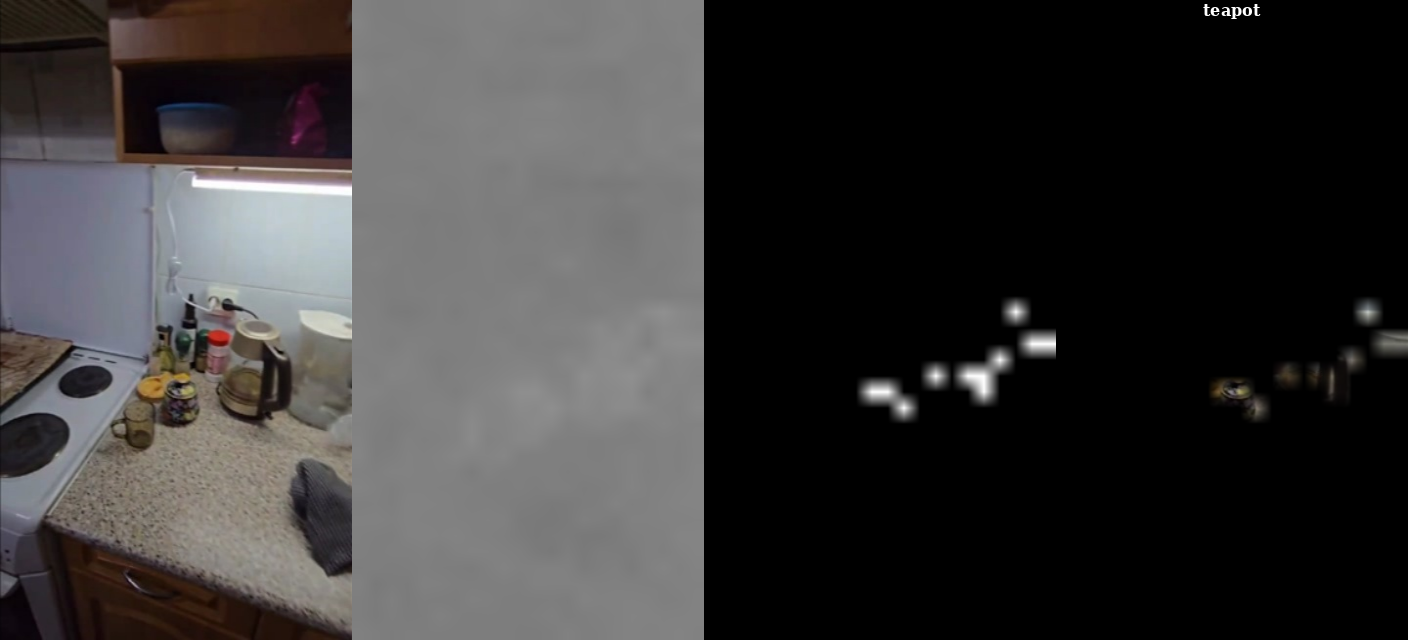

In [13]:
results[1]

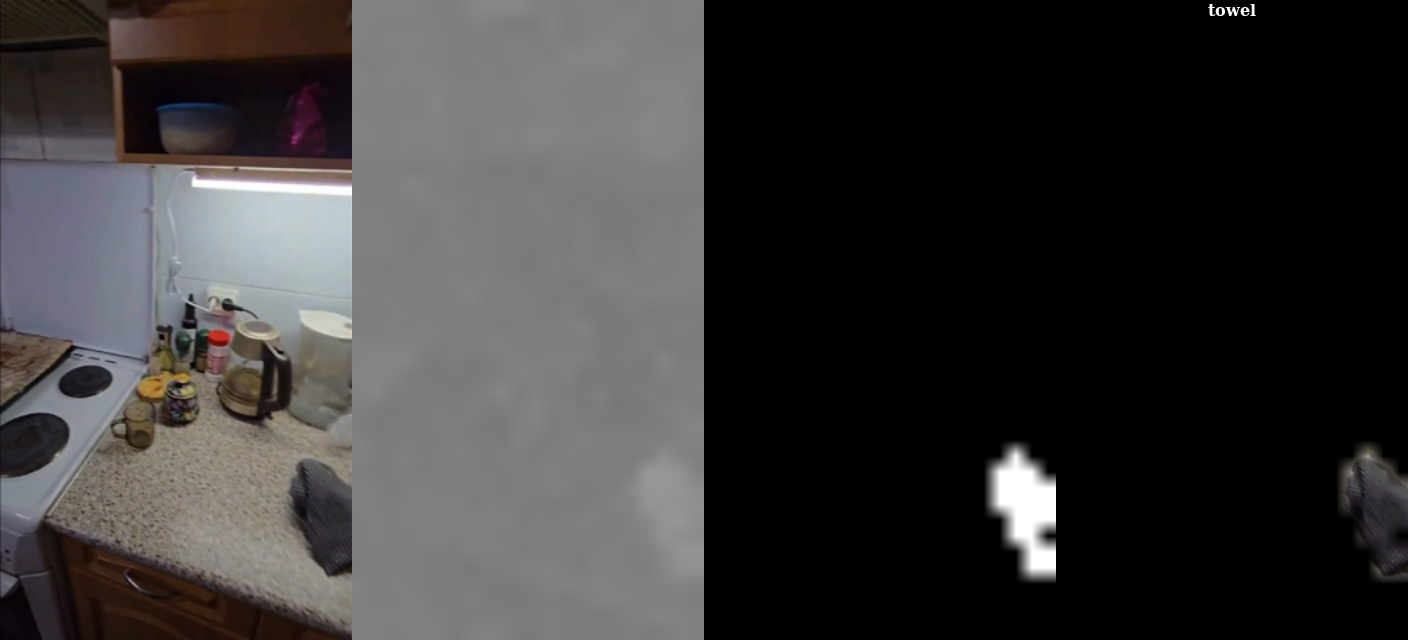

In [14]:
results[2]